In [1]:

# Import Pandas for data manipulation
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import seasonal_decompose for time-series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Import display function for better table output in Jupyter/Colab
from IPython.display import display

print("All libraries imported successfully!")


All libraries imported successfully!


In [25]:
# URL of the AirPassengers dataset
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/air-passengers/AirPassengers.csv"

# Read the CSV file into a Pandas DataFrame
df = pd.read_csv(url)

print("Dataset loaded successfully!")

display(df)


Dataset loaded successfully!


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [26]:
print("First 5 rows:")
display(df.head())


First 5 rows:


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [27]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [28]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(144, 2)


In [29]:
print("Column names:")
print(df.columns)


Column names:
Index(['Month', '#Passengers'], dtype='object')


In [32]:
print("Data types:")
print(df.dtypes)


Data types:
Month          object
#Passengers     int64
dtype: object


In [33]:
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Month          object
#Passengers     int64
dtype: object


In [34]:
print("Dataset after converting Month to datetime:")
display(df.head())



Dataset after converting Month to datetime:


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [35]:

df.set_index("Month", inplace=True)

print("Dataset after setting Month as index:")
display(df.head())


Dataset after setting Month as index:


,#Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [36]:
print("Index:")
print(df.index)

Index:
Index(['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06',
       '1949-07', '1949-08', '1949-09', '1949-10',
       ...
       '1960-03', '1960-04', '1960-05', '1960-06', '1960-07', '1960-08',
       '1960-09', '1960-10', '1960-11', '1960-12'],
      dtype='object', name='Month', length=144)


In [37]:
print("DataFrame information:")
print(df.info())

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1949-01 to 1960-12
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2+ KB
None


In [38]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
#Passengers    0
dtype: int64


In [39]:
print("Statistical summary:")
print(df.describe())

Statistical summary:
       #Passengers
count   144.000000
mean    280.298611
std     119.966317
min     104.000000
25%     180.000000
50%     265.500000
75%     360.500000
max     622.000000


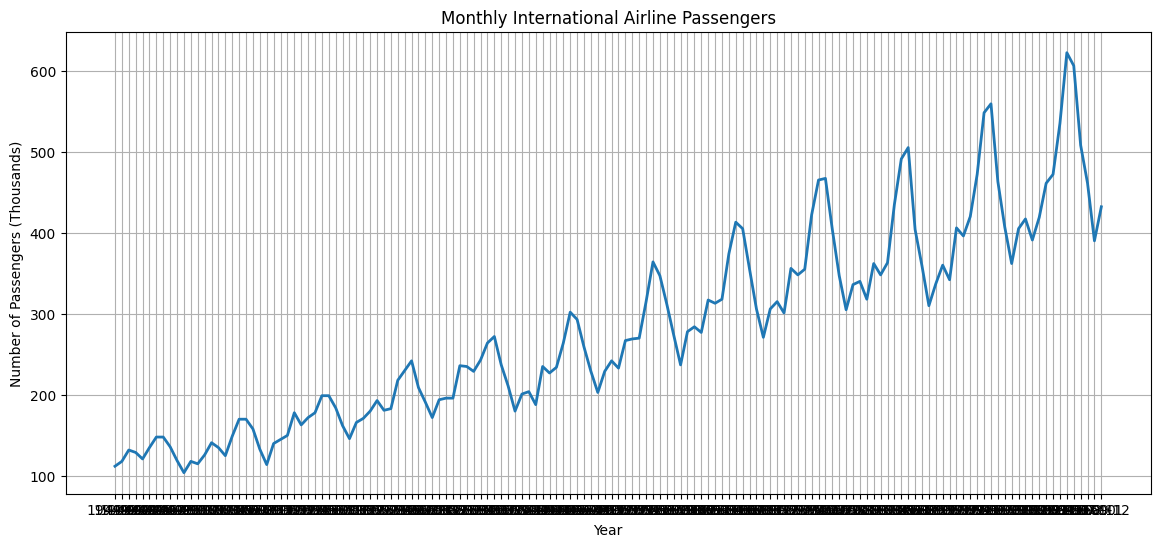

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df["#Passengers"],
    linewidth=2
)

plt.title("Monthly International Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Number of Passengers (Thousands)")

plt.grid(True)

plt.show()


Seasonal period: 12
Reason: The data is monthly and one year contains 12 months.
Decomposition completed successfully!


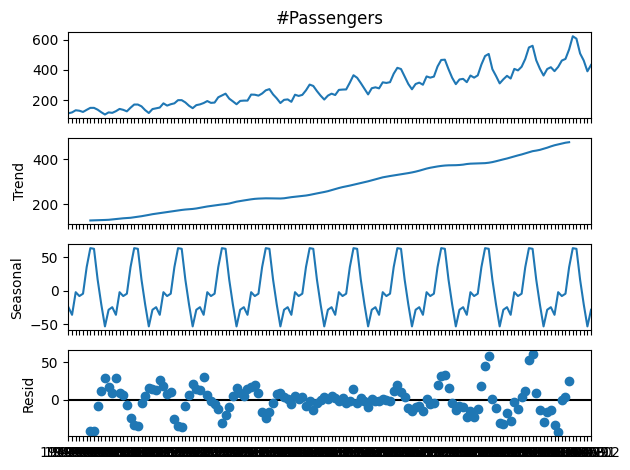

In [41]:
seasonal_period = 12

print("Seasonal period:", seasonal_period)
print("Reason: The data is monthly and one year contains 12 months.")

decomposition = seasonal_decompose(
    df["#Passengers"],
    model="additive",
    period=12
)

print("Decomposition completed successfully!")

decomposition.plot()

plt.show()


In [42]:
observed = decomposition.observed

print("Observed component:")
display(observed.head(10))



Observed component:


,#Passengers
Month,
1949-01,112.0
1949-02,118.0
1949-03,132.0
1949-04,129.0
1949-05,121.0
1949-06,135.0
1949-07,148.0
1949-08,148.0
1949-09,136.0


In [43]:
trend = decomposition.trend

print("Trend component:")
display(trend.head(15))


Trend component:


,trend
Month,
1949-01,NaN
1949-02,NaN
1949-03,NaN
1949-04,NaN
1949-05,NaN
1949-06,NaN
1949-07,126.791667
1949-08,127.250000
1949-09,127.958333


In [44]:
seasonal = decomposition.seasonal

print("Seasonal component:")
display(seasonal.head(15))


Seasonal component:


,seasonal
Month,
1949-01,-24.748737
1949-02,-36.188131
1949-03,-2.241162
1949-04,-8.036616
1949-05,-4.506313
1949-06,35.402778
1949-07,63.830808
1949-08,62.823232
1949-09,16.520202


In [45]:
residual = decomposition.resid

print("Residual component:")
display(residual.head(15))


Residual component:


,resid
Month,
1949-01,NaN
1949-02,NaN
1949-03,NaN
1949-04,NaN
1949-05,NaN
1949-06,NaN
1949-07,-42.622475
1949-08,-42.073232
1949-09,-8.478535


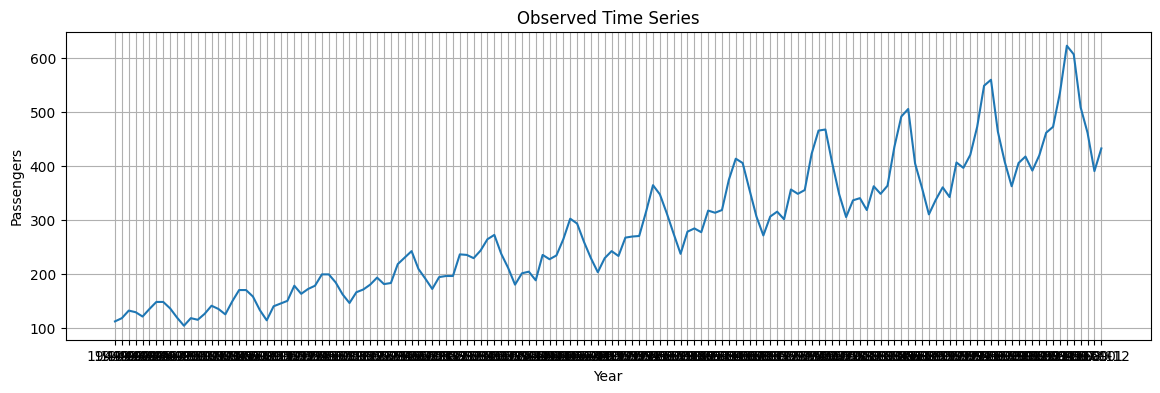

In [46]:
plt.figure(figsize=(14, 4))

plt.plot(observed)

plt.title("Observed Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")

plt.grid(True)

plt.show()
